This notebook follows on from the learning rate experiments, the spatial cv investigation, and also after the work in the SLX Proof of Concept notebook established slx as the best choice for a spatially aware model. That notebook is a foundation for this one (or this one extends the previous ones). 

So far, we have demonstrated the presence of overfitting in the original models and tried to both mitigate and quantify it. The expansion of the sample to other cities was successful, which is why this notebook will now compare the ridge and slx models using the most recent multi city data. This expansion has been shown to reduce but not eliminate a gap between test and train r2 (used to quantify overfitting). We have also implemented spatial cross validation (using clusters of lsoas to hold out) and shown that the model does have a dependency on spatial proximity. That is, it fail if asked to predict the score of an lsoa with no nearby lsoas in the training data. From those findings, we will use spatial cv with k=10 as the standard evaluation method in this notebook. 

In this notebook, i am specifically interested in how slx and ridge compare on specific feature sets. I don't think that a finding from comparing the two models on any configuration of features will hold generally. This is for a few reasons:
- I think the dimensionality reduction method might matter. If the remaining componants are less interpretable, perhaps the spatial information extracted is less useful. 
- slx will become susceptable to the curse of dimensionality much sooner than ridge, since it essentially doubles the feature space. There will be a trade off between adding more signal through new features and resisting too many features, and that balance point will be different for the two models.
- we already have a way of including some spatially aware features without slx - the osm features can include a buffer that extracts information within a certain distance of the lsoa.

# Ridge vs SLX

compare the two models using the same evalutation, and same configuration of features (engineered_rates_v2). We will use the alpha for ridge found in previous values, but sweep for the best alpha for slx (extra features means there could be a new best alpha)

In [2]:
import numpy as np
import polars as pl
import pandas as pd
from functools import partial
from project_paths import paths, project_root
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, GroupKFold
from imd_features.config import FeatureSetConfig
from imd_features.process import create_feature_set
from imd_features.spatial_utils import fetch_spatial_support_data
from imd_features.cross_validate import cross_validate, extend_slx

In [3]:
engineered_features_path = project_root / "data" / "output" / "engineered_rates_v2_c3ad0464.parquet"

df_features = pl.read_parquet(engineered_features_path)
target_df = pl.read_parquet(paths.reference)
combined = df_features.join(target_df, on="lsoa_code", how="inner")

feature_cols = [c for c in df_features.columns if c not in ("lsoa_code", "score", "rank")]
lsoa_codes = combined.get_column("lsoa_code").to_list()
X = combined.select(feature_cols).to_numpy()
y = combined.select("score").to_numpy().ravel()

print(X.shape, y.shape, len(feature_cols))

(268, 54) (268,) 54


In [4]:
W, groups, aligned_codes = fetch_spatial_support_data(
    lsoa_codes=lsoa_codes,
    boundaries_path=paths.polygons,
    lookup_path=paths.lads,
    n_clusters_per_city=10,
)

spatial_cv = GroupKFold(n_splits=5)
slx_fn = partial(extend_slx, W=W)

In [5]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]

ridge_results = {}
slx_results = {}

for alpha in alphas:
    model = Ridge(alpha=alpha)

    ridge_results[alpha] = cross_validate(X, y, model, spatial_cv, groups=groups)
    slx_results[alpha] = cross_validate(X, y, model, spatial_cv, groups=groups, extend_func=slx_fn)

    print(f"alpha: {alpha}\n Ridge R2: {ridge_results[alpha]['r2_mean']}\n SLX R2:{slx_results[alpha]['r2_mean']}")

alpha: 0.001
 Ridge R2: 0.925290773503211
 SLX R2:0.8200331243240855
alpha: 0.01
 Ridge R2: 0.9257602779491918
 SLX R2:0.830691891646383
alpha: 0.1
 Ridge R2: 0.9261528825404968
 SLX R2:0.8588674916129868
alpha: 1
 Ridge R2: 0.9260993956849255
 SLX R2:0.8994028708284031
alpha: 10
 Ridge R2: 0.9150907386191488
 SLX R2:0.9032405291610983
alpha: 100
 Ridge R2: 0.8134745200593857
 SLX R2:0.799955324564667
alpha: 500
 Ridge R2: 0.6026788933678696
 SLX R2:0.5648735885268414
alpha: 1000
 Ridge R2: 0.4349947730764761
 SLX R2:0.3991733938316921


In [6]:
rows = []
for alpha in alphas:
    rows.append({
        "model": "ridge",
        "alpha": alpha,
        "r2_mean": ridge_results[alpha]["r2_mean"],
        "r2_std": ridge_results[alpha]["r2_std"],
        "rmse_mean": ridge_results[alpha]["rmse_mean"],
        "spearman_mean": ridge_results[alpha]["spearman_mean"],
    })
    rows.append({
        "model": "slx",
        "alpha": alpha,
        "r2_mean": slx_results[alpha]["r2_mean"],
        "r2_std": slx_results[alpha]["r2_std"],
        "rmse_mean": slx_results[alpha]["rmse_mean"],
        "spearman_mean": slx_results[alpha]["spearman_mean"],
    })

summary = pd.DataFrame(rows)
summary

,model,alpha,r2_mean,r2_std,rmse_mean,spearman_mean
0,ridge,0.001,0.925291,0.028539,3.613109,0.923579
1,slx,0.001,0.820033,0.033921,5.831034,0.850458
2,ridge,0.010,0.925760,0.028478,3.602396,0.923953
3,slx,0.010,0.830692,0.040617,5.591898,0.859081
4,ridge,0.100,0.926153,0.027536,3.607689,0.925437
5,slx,0.100,0.858867,0.025849,5.145832,0.876108
6,ridge,1.000,0.926099,0.022935,3.673788,0.927302
7,slx,1.000,0.899403,0.022256,4.431498,0.908688
8,ridge,10.000,0.915091,0.020161,4.038508,0.934973
9,slx,10.000,0.903241,0.021893,4.360622,0.920659


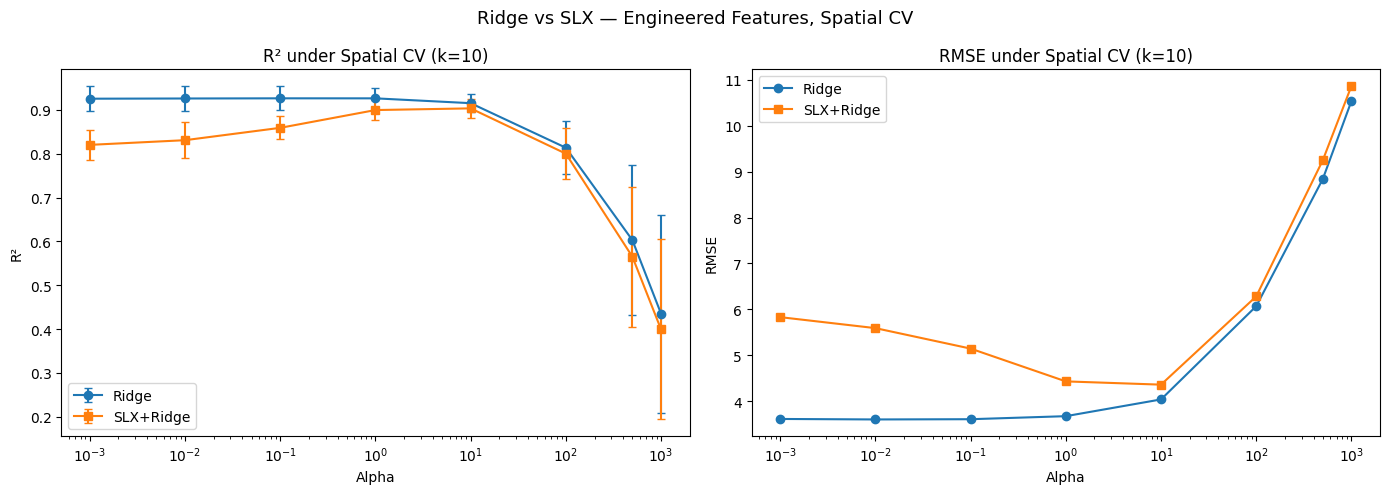

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ridge_r2 = [ridge_results[a]["r2_mean"] for a in alphas]
ridge_r2_std = [ridge_results[a]["r2_std"] for a in alphas]
slx_r2 = [slx_results[a]["r2_mean"] for a in alphas]
slx_r2_std = [slx_results[a]["r2_std"] for a in alphas]

axes[0].errorbar(alphas, ridge_r2, yerr=ridge_r2_std, label="Ridge", marker="o", capsize=3)
axes[0].errorbar(alphas, slx_r2, yerr=slx_r2_std, label="SLX+Ridge", marker="s", capsize=3)
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R²")
axes[0].set_title("R² under Spatial CV (k=10)")
axes[0].legend()

ridge_rmse = [ridge_results[a]["rmse_mean"] for a in alphas]
slx_rmse = [slx_results[a]["rmse_mean"] for a in alphas]

axes[1].plot(alphas, ridge_rmse, label="Ridge", marker="o")
axes[1].plot(alphas, slx_rmse, label="SLX+Ridge", marker="s")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE under Spatial CV (k=10)")
axes[1].legend()

fig.suptitle("Ridge vs SLX — Engineered Features, Spatial CV", fontsize=13)
fig.tight_layout()
plt.show()

for this config of features, it seems that ridge actually always outperforms slx. Im not completely suprised - we know that htis feature config contains several features extracted from OSM at a buffer of 1000 metres. This means that the slx is double extracting spatial information, which is likely to provide more noise than signal imo. 

Next would be to repeat on a feature set that contains only features with a buffer of 0.


things:
- ridge consistantly outperforms slx 
- gap is larger when alpha is smaller. explained because at small alpha the model does a worse job at regularising the doubled feature space of slx
- looks like optimal alpha for slx is higher than for ridge (ridge around 1, slx around 10, finer tuning needed to be certain of more exact values)
- the performance converging could be because at the higher alpha value r2 reg shrinks all the spatial lag features and the slx model becomes almost totally equivilent to the baseline
- the implication for model selection is that we should either
    - use ridge and engineer all the spatial features we want explicitly
    - find a different feature set where slx outperforms the baseline
    - explore using slx derived spatial features with a different model e.g. we can calculate the spatial lag feature matrix, append it to the feature matrix, then use it to train a random forest
    

in the next section im going to explore a hypothesis that slx isn't outperforming the baseline ridge in the scenarios we've tried it in so far because its suffering from the curse of dimensionality. Its feature space is doubled compared to the baseline, and this could have a significant effect given the number of features and the sample size we're using so far. 

To test this, im going to design three new feature sets ranging from extremely small and focused back up to similar sizes we've tried so far. When coming up with the configs, i'll take into account everything learned about the features and modelling in previous experiments. This will include:
    - using rates instead of raw values. especially in the smaller config, we can capture more signal in fewer featues and avoid correlated features. We saw that including rates provided the best results so far with the linear models, so it makes sense to continue. This can be extended to more features as well. With rates included, the population values will be excluded.
    - exclude connectivity, for two reasons. One, they are inherently spatial so its hard to interpret how calculating a spatial lag of these encodes information, but its probably a dubious methodology. And two, we wont be using it with 2019 data anyway.
    - exclude all osm features that use a buffer. We want to only use counts of amenites within the lsoa. This then defers all proximal information to the slx theta matrix. This means excluding all the ratios of amenity types since we never calculated these at 0 buffer. This is fine, as we still get up to ~50 features, which is a size where we know ridge baseline has already outperformed slx

if the hypothesis is correct, we could see slx outperforming ridge using the smaller configs before crossing over as we get to the medium or larger one. 

other considerations:

we will retune alpha for every config since different amount of regularisation will be need when the number of features changes.

if we need to, we can add a fourth config to try and pinpoint the crossover.


We won't use any dimensionality reduction in these configs. We are purely looking for how the performance of each modelling approach changes when the number of features changes, not the absolute performance. Since both have the same underlying linear regression method, they should both learn from the same features when present. If more information about the appropriate number of features to use with slx is found, this can be used to inform the design of feature configs for slx that use dimensionality reduction to get to that number. 


In [8]:
from imd_features.config import GroupConfig

small_config = FeatureSetConfig(
    name="slx_experiment_small",
    description="8 non-spatial features, one rate per domain, no population",
    groups={
        "crime": GroupConfig(columns=["crime_rate_per_1000"]),
        "uc": GroupConfig(columns=["uc_claim_rate"]),
        "land_registry": GroupConfig(columns=[
            "lsoa_mean_price",
            "transactions_per_capita",
            "flats_proportion",
        ]),
        "osm_landuse": GroupConfig(columns=[
            "landuse_residential_0",
            "landuse_industrial_0",
            "streetlit_percentage",
        ]),
    },
)

medium_config = FeatureSetConfig(
    name="slx_experiment_medium",
    description="22 non-spatial features, broader domain coverage, no buffers",
    groups={
        "crime": GroupConfig(columns=[
            "crime_rate_per_1000",
            "violent_crime_rate",
            "asb_rate",
            "burglary_rate",
            "drugs_rate",
            "resolution_rate",
        ]),
        "uc": GroupConfig(columns=[
            "uc_claim_rate",
            "uc_nwr_rate",
            "%_claims_planfw",
            "%_claims_sfw",
        ]),
        "land_registry": GroupConfig(columns=[
            "lsoa_mean_price",
            "lsoa_median_price",
            "lsoa_price_inequality",
            "transactions_per_capita",
            "flats_proportion",
            "terraced_proportion",
            "detached_proportion",
            "freehold_proportion",
        ]),
        "osm_landuse": GroupConfig(columns=[
            "landuse_residential_0",
            "landuse_industrial_0",
            "landuse_commercial_0",
            "streetlit_percentage",
        ]),
    },
)

large_config = FeatureSetConfig(
    name="slx_experiment_large",
    description="~50 non-spatial features, all domains, 0m amenity counts, no buffers",
    groups={
        "crime": GroupConfig(columns=[
            "crime_rate_per_1000",
            "violent_crime_rate",
            "asb_rate",
            "burglary_rate",
            "drugs_rate",
            "resolution_rate",
        ]),
        "uc": GroupConfig(columns=[
            "uc_claim_rate",
            "uc_nwr_rate",
            "%_claims_planfw",
            "%_claims_sfw",
        ]),
        "land_registry": GroupConfig(columns=[
            "lsoa_mean_price",
            "lsoa_median_price",
            "lsoa_price_inequality",
            "transactions_per_capita",
            "flats_proportion",
            "terraced_proportion",
            "detached_proportion",
            "freehold_proportion",
            "new_build_proportion",
        ]),
        "osm_counts": GroupConfig(columns=[
            "count_healthcare_access_0",
            "count_education_skills_0",
            "count_essential_services_0",
            "count_transport_public_0",
            "count_financial_services_0",
            "count_retail_commerce_0",
            "count_fast_food_takeaway_0",
            "count_food_dining_0",
            "count_alcohol_gambling_0",
            "count_community_social_0",
            "count_cultural_entertainment_0",
            "count_sustainable_transport_0",
            "count_childcare_early_years_0",
            "count_social_support_0",
        ]),
        "osm_landuse": GroupConfig(columns=[
            "landuse_residential_0",
            "landuse_industrial_0",
            "landuse_commercial_0",
            "landuse_grass_0",
            "landuse_retail_0",
            "landuse_education_0",
            "landuse_recreation_ground_0",
            "streetlit_percentage",
        ]),
        "population": GroupConfig(columns=[
            "youth_share",
            "elderly_share",
        ]),
    },
)

configs = {
    "small": small_config,
    "medium": medium_config,
    "large": large_config,
}

In [9]:
raw = pl.read_parquet(project_root / "data" / "input" / "combined_data_multi_city.parquet")

engineered = raw.with_columns(
    (pl.col("total_crimes") / pl.col("lsoa_population") * 1000).alias("crime_rate_per_1000"),
    (pl.col("violent-crime") / pl.col("lsoa_population") * 1000).alias("violent_crime_rate"),
    (pl.col("anti-social-behaviour") / pl.col("lsoa_population") * 1000).alias("asb_rate"),
    (pl.col("burglary") / pl.col("lsoa_population") * 1000).alias("burglary_rate"),
    (pl.col("drugs") / pl.col("lsoa_population") * 1000).alias("drugs_rate"),
    (pl.col("total_claims") / pl.col("working_age_population")).alias("uc_claim_rate"),
    (pl.col("total_nwr_claims") / pl.col("working_age_population")).alias("uc_nwr_rate"),
    (pl.col("total_transactions") / pl.col("lsoa_population") * 1000).alias("transactions_per_capita"),
    (pl.col("aged_under_15") / pl.col("lsoa_population")).alias("youth_share"),
    (pl.col("pension_age_population") / pl.col("lsoa_population")).alias("elderly_share"),
)

input_path = project_root / "data" / "input" / "combined_engineered_slx_experiment.parquet"
engineered.write_parquet(input_path)

In [ ]:
# datasets = {
#     name: df 
#     for name, config in configs.items()
#     for df, _ in create_feature_set(input_data=input_path,config=config)
# }

datasets = {}
for name, config in configs.items():

    df, *_ = create_feature_set(input_path, config)
    combined_cfg = df.join(target_df, on="lsoa_code", how="inner")
    feat_cols = [c for c in df.columns if c not in ("lsoa_code", "score", "rank")]

    X_cfg = combined_cfg.select(feat_cols).to_numpy()
    y_cfg = combined_cfg.select("score").to_numpy().ravel()

    datasets[name] = {"X": X_cfg, "y": y_cfg, "n_features": len(feat_cols)}

In [11]:
alphas = [0.01, 0.1, 0.5, 1, 3, 10, 100, 500, 1000]

dimension_results = {}

for name, data in datasets.items():
    X_d, y_d = data["X"], data["y"]
    ridge_res = {}
    slx_res = {}

    for alpha in alphas:
        model = Ridge(alpha=alpha)
        ridge_res[alpha] = cross_validate(X_d, y_d, model, spatial_cv, groups=groups)
        slx_res[alpha] = cross_validate(X_d, y_d, model, spatial_cv, groups=groups, extend_func=slx_fn)

    best_ridge_alpha = max(ridge_res, key=lambda a: ridge_res[a]["r2_mean"])
    best_slx_alpha = max(slx_res, key=lambda a: slx_res[a]["r2_mean"])

    dimension_results[name] = {
        "n_features": data["n_features"],
        "ridge_best_alpha": best_ridge_alpha,
        "ridge_best_r2": ridge_res[best_ridge_alpha]["r2_mean"],
        "ridge_best_r2_std": ridge_res[best_ridge_alpha]["r2_std"],
        "slx_best_alpha": best_slx_alpha,
        "slx_best_r2": slx_res[best_slx_alpha]["r2_mean"],
        "slx_best_r2_std": slx_res[best_slx_alpha]["r2_std"],
        "slx_minus_ridge": slx_res[best_slx_alpha]["r2_mean"] - ridge_res[best_ridge_alpha]["r2_mean"],
        "ridge_all": ridge_res,
        "slx_all": slx_res,
    }


c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.975064801552031e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.75487739658301e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.754718824071053e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.589499351616584

In [12]:
from pprint import pprint

pprint(dimension_results)

{'large': {'n_features': 43,
           'ridge_all': {0.01: {'r2_mean': 0.9436811581326943,
                                'r2_per_fold': [0.9206624956975872,
                                                0.9503578578502448,
                                                0.947059453284138,
                                                0.969041721909627,
                                                0.9312842619218742],
                                'r2_std': 0.016629439246683794,
                                'rmse_mean': 3.186570471755085,
                                'rmse_per_fold': [np.float64(3.8250405350767416),
                                                  np.float64(3.004765190015478),
                                                  np.float64(2.852195669417333),
                                                  np.float64(3.2427352942862817),
                                                  np.float64(3.0081156699795906)],
                                

In [13]:
for name, data in dimension_results.items():
    print(f"\n{name} ({data['n_features']} features):")
    print(f"\tRidge:\talpha={data["ridge_best_alpha"]},\tR2={data["ridge_best_r2"]} +- {data["ridge_best_r2_std"]}")
    print(f"\tSLX:\talpha={data["slx_best_alpha"]},\tR2={data["slx_best_r2"]} +- {data["slx_best_r2_std"]}")
    # print(f"  delta:     {slx_res[best_slx_alpha]['r2_mean'] - ridge_res[best_ridge_alpha]['r2_mean']:+.3f}")


small (8 features):
	Ridge:	alpha=0.5,	R2=0.9431686372189299 +- 0.017841784091903946
	SLX:	alpha=0.5,	R2=0.9338157798305042 +- 0.01071571264881497

medium (22 features):
	Ridge:	alpha=0.5,	R2=0.9446563581837207 +- 0.014606035496561278
	SLX:	alpha=0.01,	R2=0.9239261272114966 +- 0.023722489437755137

large (43 features):
	Ridge:	alpha=0.1,	R2=0.9443654042229899 +- 0.016851469099998597
	SLX:	alpha=0.1,	R2=0.9272953519975153 +- 0.024958030697835306


In [ ]:
summary_rows = []
for name, res in dimension_results.items():
    summary_rows.append({
        "config": name,
        "n_features": res["n_features"],
        "n_features_slx": res["n_features"] * 2,
        "ridge_best_alpha": res["ridge_best_alpha"],
        "ridge_r2": res["ridge_best_r2"],
        "ridge_r2_std": res["ridge_best_r2_std"],
        "slx_best_alpha": res["slx_best_alpha"],
        "slx_r2": res["slx_best_r2"],
        "slx_r2_std": res["slx_best_r2_std"],
        "slx_minus_ridge": res["slx_minus_ridge"],
    })

dimension_summary = pd.DataFrame(summary_rows)
dimension_summary.index.name = None
dimension_summary

,config,n_features,n_features_slx,ridge_best_alpha,ridge_r2,ridge_r2_std,slx_best_alpha,slx_r2,slx_r2_std,slx_minus_ridge
0,small,8,16,0.5,0.943169,0.017842,0.50,0.933816,0.010716,-0.009353
1,medium,22,44,0.5,0.944656,0.014606,0.01,0.923926,0.023722,-0.020730
2,large,43,86,0.1,0.944365,0.016851,0.10,0.927295,0.024958,-0.017070


## thoughts

results are extremely close

slx makes performance worse in every case

slx does get worse as feature space increases, even though the baseline increases slightly.

most importantly, we get the same results with just eight features. 

originally, i thought that since we demonstrated that the model was spatially dependent (needs nearby training examples to make good predictions) then we would see that spatial features are important and improve the model. It turns out that thats not the case, and the two facts neednt follow from one another.

The spatial dependence must just be inherent in the data - nearby lsoas have similar ons imd scores, and also the house prices will be similar, the distribution of crime rates could be similar, the uc claims could be similar, all following smooth curves (im speculating). But the model doesn't necessarily have to learn anything about the spatial distribution of features to be good, it can just use the ones for each lsoa to predict each lsoa and get really close to the answer. 

I think this must tell us something about the ONS official methodology.

sketching out an idea here about what we learn about ONS methodology through this research.

ONS uses lots of inputs (100s) from multiple domains, then some complex (or complex looking) formulas along with some weights (produced through a seemingly opaque process), rankings, transformations, ect. . We have been able to capture 95% of the variation of this using a single linear model and eight inputs. I think its very interesting that this essentially colapses down into something much simpler. 

This is r2=0.95 replicating the **index** from ONS, which we have designated as ground truth for this project. There must also be a concept of true deprivation (which ons is trying to measure). I think, intuitively, that deprivation is spatially dependent in a important contextual way. I think that deprivation is a phenomenn that presents differently depending on the geographic context, and therefore a good measure of true deprevation should encode geographic context. The same precence of or pattern in features in an lsoa in a rural part of the south west should not indicate that it has the same level of deprevation that the same precence/pattern indicates if that lsoa was in central london. For example, distance the closest school or hospital should have a different feature importance in rural vs urban settings. I think that the fact that we capture the ONS index using a simple linear model with **no spatial effects at all** suggest to me that you could pick up an lsoa from london, place it in north somerset and its score would stay the same if its features were the same. I think this demonstrates a possible failure mode in the current methodology.


according to claude, we can sum this idea up in a more formal way thus: "the IMD's apparent complexity reduces to a low-dimensional linear structure, and that structure contains no spatial information. Given domain knowledge about how deprivation manifests differently across spatial contexts, this suggests the IMD may be missing important variation."

It's reference to domain knowledge might be overdoing it a bit - this is more based on intuition, common sense, thinking about the problem for a while than actual domain expertise. We would have to do a bit of reading about geographic setting affecting socio economic indicators. im sure these must be plentiful.

## next steps

at this point, i was going to add a third section to the notebook exploring the difference between using the spatial features calculated with a buffer from osm data and the spatial lag effects (could slx sub for all buffer based feature engineering, or should all spatial features be explicitly engineered and no slx included).
But this seems now to be a very low value task since it looks like both are unnecessary. If we decide to explicitly explore importance of spatial features, this is probably better done with a model that appends slx matrix to the original feature matrix and trains random forest/xgboost, since with the tree based architecture we have access to feature importance/shap analysis. 